<a href="https://colab.research.google.com/github/FBL9207-source/Healthcare-ETL-MiniProject/blob/main/Preprocessing_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
daimond_data = pd.read_csv("/content/diamonds_new.csv")

In [ ]:
daimond_data.head()

,carat,cut,color,clarity,table,x,y,z,price_new
0,0.23,Ideal,E,SI2,55.0,3.95,3.98,2.43,163.0
1,0.21,Premium,E,SI1,61.0,3.89,3.84,2.31,163.0
2,0.23,Good,E,VS1,65.0,4.05,4.07,2.31,163.5
3,0.29,Premium,I,VS2,58.0,4.20,4.23,2.63,167.0
4,0.31,Good,J,SI2,58.0,4.34,4.35,2.75,167.5


In [ ]:
daimond_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53841 non-null  float64
 1   cut        53940 non-null  object 
 2   color      53884 non-null  object 
 3   clarity    53940 non-null  object 
 4   table      53877 non-null  float64
 5   x          53940 non-null  float64
 6   y          53940 non-null  float64
 7   z          53940 non-null  float64
 8   price_new  53940 non-null  float64
dtypes: float64(6), object(3)
memory usage: 3.7+ MB


In [ ]:
daimond_data.describe()

,carat,table,x,y,z,price_new
count,53841.000000,53877.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.798120,57.457719,5.731157,5.734526,3.539635,1966.399861
std,0.474428,2.235742,1.121761,1.142135,0.703869,1994.719869
min,0.200000,43.000000,0.000000,0.000000,0.000000,163.000000
25%,0.400000,56.000000,4.710000,4.720000,2.910000,475.000000
50%,0.700000,57.000000,5.700000,5.710000,3.530000,1200.500000
75%,1.040000,59.000000,6.540000,6.540000,4.040000,2662.125000
max,5.010000,95.000000,10.740000,58.900000,31.800000,9411.500000


In [ ]:
daimond_data.isna().sum()

,0
carat,99
cut,0
color,56
clarity,0
table,63
x,0
y,0
z,0
price_new,0


In [ ]:
daimond_data[(daimond_data['x'] == 0) | (daimond_data['y'] == 0) | (daimond_data['z'] == 0)]

,carat,cut,color,clarity,table,x,y,z,price_new
11182,1.07,Ideal,F,SI2,56.0,0.0,6.62,0.0,2477.0
11963,1.00,Very Good,H,VS2,53.0,0.0,0.00,0.0,2569.5
15951,1.14,Fair,G,VS1,67.0,0.0,0.00,0.0,3190.5
24520,1.56,Ideal,G,VS2,54.0,0.0,0.00,0.0,6400.0
26243,1.20,Premium,D,VVS1,59.0,0.0,0.00,0.0,7843.0
27429,2.25,Premium,H,SI2,59.0,0.0,0.00,0.0,9017.0
49556,0.71,Good,F,SI2,60.0,0.0,0.00,0.0,1065.0
49557,0.71,Good,F,SI2,60.0,0.0,0.00,0.0,1065.0


In [ ]:
daimond_data = daimond_data[(daimond_data['x'] != 0) & (daimond_data['y'] != 0) & (daimond_data['z'] != 0)]

In [ ]:
daimond_data.describe()

,carat,table,x,y,z,price_new
count,53833.000000,53869.000000,53932.000000,53932.000000,53932.00000,53932.000000
mean,0.798059,57.457564,5.732007,5.735254,3.54016,1966.068039
std,0.474403,2.235315,1.119670,1.140343,0.70260,1994.367418
min,0.200000,43.000000,3.730000,3.680000,1.07000,163.000000
25%,0.400000,56.000000,4.710000,4.720000,2.91000,474.875000
50%,0.700000,57.000000,5.700000,5.710000,3.53000,1200.500000
75%,1.040000,59.000000,6.540000,6.540000,4.04000,2662.000000
max,5.010000,95.000000,10.740000,58.900000,31.80000,9411.500000


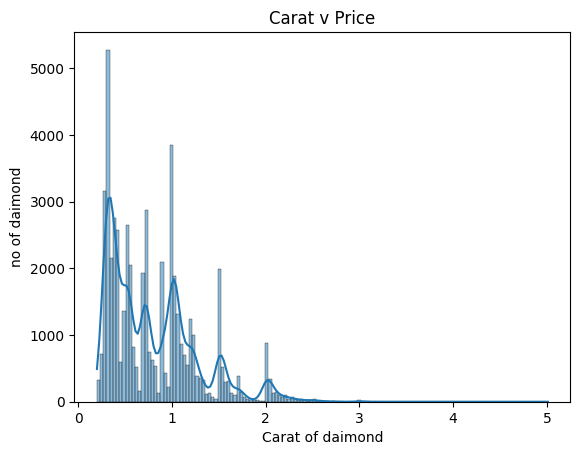

In [ ]:
sns.histplot(daimond_data["carat"],kde =True)
plt.xlabel("Carat of daimond")
plt.ylabel("no of daimond")
plt.title("Carat v Price")
plt.show()

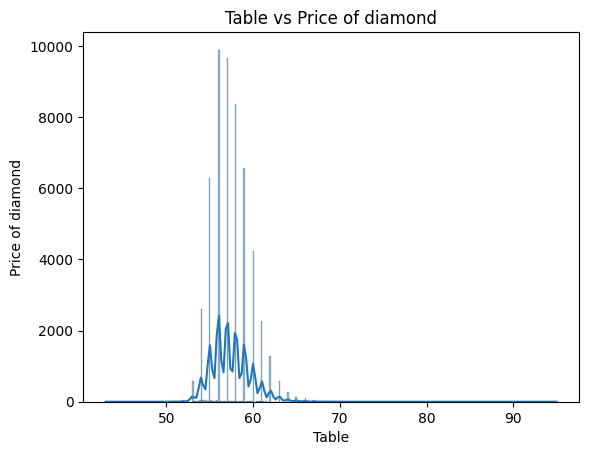

In [ ]:
sns.histplot(daimond_data["table"],kde =True)
plt.xlabel("Table")
plt.ylabel("Price of diamond")
plt.title("Table vs Price of diamond")
plt.show()

#Filling Missing values using simple imputer

In [ ]:
#Filling missing  values using mean
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy= 'median')
daimond_data["carat"] = imputer1.fit_transform(daimond_data[["carat"]])

In [ ]:
daimond_data["table"] = imputer1.fit_transform(daimond_data[["table"]])

In [ ]:
daimond_data.isna().sum()

,0
carat,0
cut,0
color,56
clarity,0
table,0
x,0
y,0
z,0
price_new,0


#Filling Missing values in non numerical data

In [ ]:
#Filling missing values using mode
imputer_col = SimpleImputer(strategy= 'most_frequent')
daimond_data[['color']] = imputer_col.fit_transform(daimond_data[['color']])

In [ ]:
daimond_data.isna().sum()

,0
carat,0
cut,0
color,0
clarity,0
table,0
x,0
y,0
z,0
price_new,0


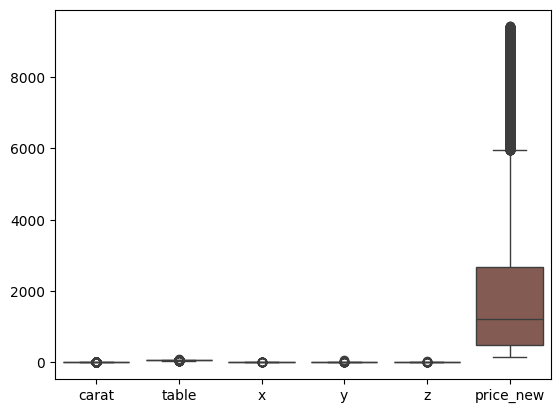

In [ ]:
sns.boxplot(daimond_data)
plt.show()

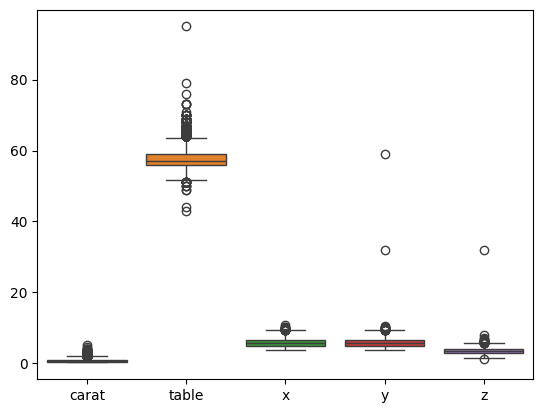

In [ ]:
num_coloumns = ['carat','table','x','y','z']
sns.boxplot(daimond_data[num_coloumns])
plt.show()

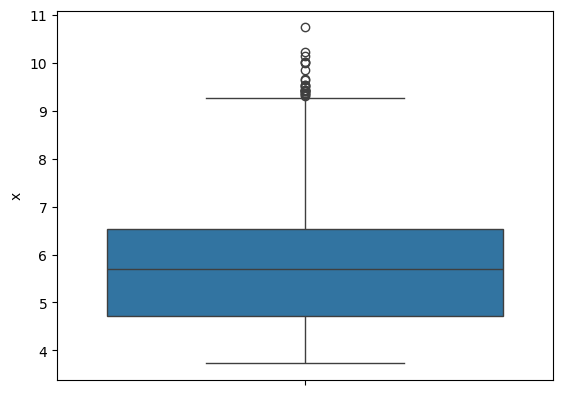

In [ ]:
sns.boxplot(daimond_data['x'])
plt.show()

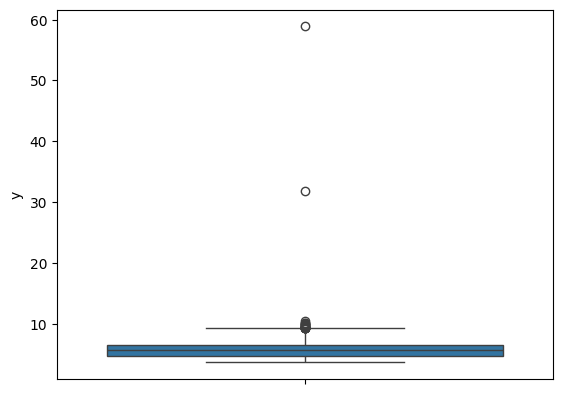

In [ ]:
sns.boxplot(daimond_data['y'])
plt.show()

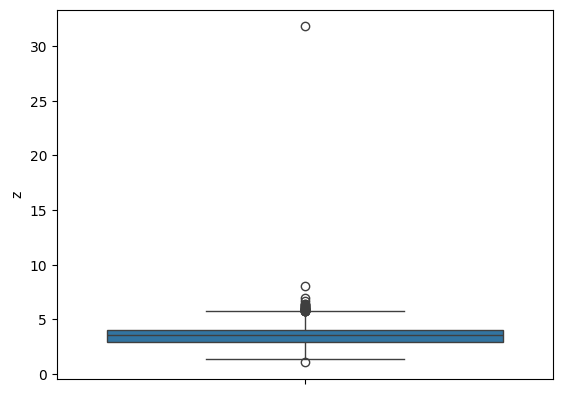

In [ ]:
sns.boxplot(daimond_data['z'])
plt.show()

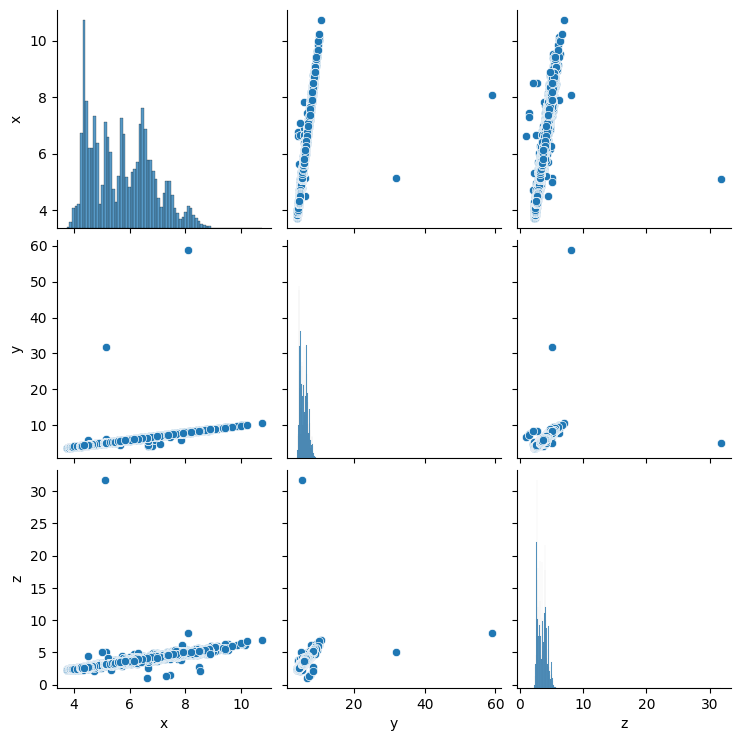

In [ ]:
sns.pairplot(daimond_data[['x','y','z']])
plt.show()

From the scatter plots and pair plot above its evident that values>30 in y and z are extreme values.instead of handling all outlierd removing these extreme values  other values are closer values

In [ ]:
daimond_data = daimond_data[(daimond_data['y'] <= 30) & (daimond_data['z'] <= 30)]

#Encoding

In [ ]:
daimond_data['cut']

,cut
0,Ideal
1,Premium
2,Good
3,Premium
4,Good
...,...
53935,Ideal
53936,Good
53937,Very Good
53938,Premium


In [ ]:
daimond_data['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
od_enc = OrdinalEncoder( categories= [['D','E', 'F', 'G', 'H', 'I', 'J']])
daimond_data['color'] = od_enc.fit_transform(daimond_data[['color']])

In [ ]:
daimond_data['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
od_enc_cut = OrdinalEncoder( categories= [['Fair','Good', 'Very Good', 'Premium', 'Ideal']])
daimond_data['cut'] = od_enc_cut.fit_transform(daimond_data[['cut']])

In [ ]:
daimond_data['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
od_enc_cla = OrdinalEncoder( categories= [['I1','SI2','SI1', 'VS2', 'VS1', 'VVS2','VVS1','IF']])
daimond_data['clarity'] = od_enc_cla.fit_transform(daimond_data[['clarity']])

In [ ]:
daimond_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53929 entries, 0 to 53939
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53929 non-null  float64
 1   cut        53929 non-null  float64
 2   color      53929 non-null  float64
 3   clarity    53929 non-null  float64
 4   table      53929 non-null  float64
 5   x          53929 non-null  float64
 6   y          53929 non-null  float64
 7   z          53929 non-null  float64
 8   price_new  53929 non-null  float64
dtypes: float64(9)
memory usage: 4.1 MB


#Scalining


In [ ]:
x = daimond_data.drop(['price_new'], axis=1)
y = daimond_data['price_new']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size= 0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
num_col = ['carat','table','x','y','z']
x_train[num_col] = scaler.fit_transform(x_train[num_col])
x_test[num_col] = scaler.transform(x_test[num_col])

In [ ]:
x_train.head()

,carat,cut,color,clarity,table,x,y,z
6428,0.469405,3.0,0.0,1.0,2.028578,0.651362,0.618465,0.595114
49798,-0.141748,4.0,2.0,1.0,-0.654591,0.142532,0.105913,-0.055341
16342,0.427256,4.0,4.0,6.0,0.686993,0.571020,0.609473,0.566205
42393,-0.710753,1.0,2.0,6.0,-1.101786,-0.857273,-0.820278,-0.503433
45353,-0.521085,3.0,1.0,3.0,2.028578,-0.321663,-0.370671,-0.546797


#Reusable Preprocessing Pipeline

In [ ]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
daimond_df = pd.read_csv('diamonds_new.csv')
daimond_df.head()

,carat,cut,color,clarity,table,x,y,z,price_new
0,0.23,Ideal,E,SI2,55.0,3.95,3.98,2.43,163.0
1,0.21,Premium,E,SI1,61.0,3.89,3.84,2.31,163.0
2,0.23,Good,E,VS1,65.0,4.05,4.07,2.31,163.5
3,0.29,Premium,I,VS2,58.0,4.20,4.23,2.63,167.0
4,0.31,Good,J,SI2,58.0,4.34,4.35,2.75,167.5


In [ ]:
#Removing unrealistic values
daimond_df = daimond_df[(daimond_df['x'] != 0) & (daimond_df['y'] != 0) & (daimond_df['z'] != 0)]
daimond_df = daimond_df[(daimond_df['x'] <= 30) & (daimond_df['y'] <= 30) & (daimond_df['z'] <= 30)]

In [ ]:
#seperate x and y
x = daimond_df.drop(['price_new'], axis=1)
y = daimond_df['price_new']

In [ ]:
#Train and split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2, random_state=42)

In [ ]:
#Define columns
numeric_col = ['carat','table','x','y','z']
categorical_col = ['cut','color','clarity']

In [ ]:
#Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [ ]:
#categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OrdinalEncoder(
        categories=[
            ['Fair','Good', 'Very Good', 'Premium', 'Ideal'],
            ['D','E', 'F', 'G', 'H', 'I', 'J'],
            ['I1','SI2','SI1', 'VS2', 'VS1', 'VVS2','VVS1','IF']

        ]))
])

In [ ]:
#combine pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numeric_col),
    ('categorical',categorical_pipeline,categorical_col)
])

In [ ]:
#Fit and trnsform training data
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed  = preprocessor.transform(x_test)


In [ ]:
x_train_processed

array([[ 0.46940489,  2.02857772,  0.65136183, ...,  3.        ,
         0.        ,  1.        ],
       [-0.14174844, -0.65459106,  0.14253223, ...,  4.        ,
         2.        ,  1.        ],
       [ 0.42725638,  0.68699333,  0.57102032, ...,  4.        ,
         4.        ,  6.        ],
       ...,
       [-0.96364431, -1.10178586, -1.11615151, ...,  4.        ,
         3.        ,  7.        ],
       [ 0.21651385,  0.68699333,  0.35677627, ...,  3.        ,
         6.        ,  2.        ],
       [ 1.03840972, -1.10178586,  1.16019143, ...,  4.        ,
         3.        ,  1.        ]])

In [ ]:
x_test_processed

array([[-0.83719879,  2.02857772, -0.89298063, ...,  3.        ,
         4.        ,  2.        ],
       [ 1.94460259, -0.20739627,  1.7136552 , ...,  4.        ,
         4.        ,  2.        ],
       [-0.47893649,  1.13418813, -0.25917534, ...,  3.        ,
         2.        ,  3.        ],
       ...,
       [-0.9214958 , -0.65459106, -1.02688316, ...,  4.        ,
         3.        ,  6.        ],
       [-0.60538201, -0.65459106, -0.53590723, ...,  4.        ,
         1.        ,  6.        ],
       [-0.45786224, -0.20739627, -0.3752242 , ...,  2.        ,
         5.        ,  6.        ]])

In [ ]:
feature_names = numeric_col + categorical_col
x_train_processed = pd.DataFrame(x_train_processed,
                                 columns = feature_names,
                                 index = x_train.index)
x_test_processed = pd.DataFrame(x_test_processed,
                                columns = feature_names,
                                 index = x_test.index)

In [ ]:
x_train_processed.head()

,carat,table,x,y,z,cut,color,clarity
6428,0.469405,2.028578,0.651362,0.618465,0.595114,3.0,0.0,1.0
49798,-0.141748,-0.654591,0.142532,0.105913,-0.055341,4.0,2.0,1.0
16342,0.427256,0.686993,0.571020,0.609473,0.566205,4.0,4.0,6.0
42393,-0.710753,-1.101786,-0.857273,-0.820278,-0.503433,1.0,2.0,6.0
45353,-0.521085,2.028578,-0.321663,-0.370671,-0.546797,3.0,1.0,3.0
